# Barometer 🌡️
### "Read the macro weather, trade the trend." A premium that points the right way in every cut — and never clears the statistics. Slow, modest, and only a storm-hedge when it storms.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Done](https://img.shields.io/badge/Real--tape_run%3F-Done-8b949e?style=flat-square)

The idea is old and intuitive: the economy has weather. When **growth** is improving, pro-cyclical assets (stocks, commodities) do well; when **inflation** is rising, *real* assets (commodities, inflation-linked bonds, gold) protect you while nominal stocks and bonds suffer. So watch the *trend* in the macro data — the barometer — and lean your portfolio the way it's pointing. This study asks the honest two-part question: is that real, and can you trade it?

> 📓 **Plain-language layer.** The macro-momentum premium, the cost/break-even, and the regime split that tests the inflation hedge are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> 🟢 **Real run done.** The numbers here are from the desk's cached tape — **18 cross-asset ETFs** plus a macro state of **CPI year-over-year** (inflation) and the **yield-curve slope** (growth), all lagged one month for publication delay, **2007-2025** ([`../docs/results.md`](../docs/results.md)). The **synthetic** cross-asset world is kept as the offline mechanism proof. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from barometer import data, strategy, costs, extension
from barometer.data import REAL_ASSETS, REAL_ASSET_ORDER
SPEC = dict(assets=REAL_ASSETS, order=REAL_ASSET_ORDER)

# Offline synthetic control: a cross-asset world whose latent macro momentum predicts returns (the
# machinery) + a macro_strength=0 null.
r, m, truth = data.synthetic_macro(macro_strength=1.0, seed=37)
r0, m0, _ = data.synthetic_macro(macro_strength=0.0, seed=37)
print(f"synthetic control: {truth.n_assets} assets x {truth.n_months} months, macro_strength {truth.macro_strength} (null=0)")

# REAL book from the desk's cached tape (18 ETFs + CPI-YoY/yield-slope macro, lagged 1m, 2007-2025), offline.
_b = data.fetch_macro()
R, M = (_b.get("assets"), _b.get("macro")) if _b else (None, None)
if R is not None:
    print(f"real book: {R.shape[1]} ETFs x {len(R)} months  {R.index.min().date()} -> {R.index.max().date()}")


synthetic control: 5 assets x 600 months, macro_strength 1.0 (null=0)


real book: 18 ETFs x 217 months  2007-02-28 -> 2025-02-28


## The answer first 🌡️

| What we asked | The honest answer (real tape, 2007-2025) |
|---|---|
| Do real assets beat nominal bonds *when inflation rises*? | 🟨 **The direction lands the right way — but it's small and uncertified.** An always-long real-asset basket out-earned Treasuries by **+1.8%/yr** in rising-inflation months and **-0.3%/yr** in falling ones — yet that spread is Sharpe **+0.10**, *t* ≈ **0.3** over 104 rising months: nowhere near the desk's bar. |
| Can you *trade* it with a monthly macro-momentum book? | 🟨 **Barely — it's weak & slow.** On the short post-2007 tape the standalone book is flat: net Sharpe **-0.05** (HAC *t* -0.22), below a passive equal-weight hold (**0.57**). |
| Does the inflation hedge pay *more* when inflation rises? | 🟨 **Yes, directionally.** Rising Sharpe **-0.08** vs falling **-0.16** — right-sided, but the timed book whipsaws under water in both over one short cycle. |
| Real cross-asset run? | 🟢 **Done** — 18 ETFs + cached macro, offline, fingerprinted. |

> Desk shorthand: **Signal `WEAK` · Tradability `FRAGILE` · Real-tape run? `DONE`** — every cut of the real tape lands on the side the theory predicts, and not one of them clears the desk's significance bar (the biggest *t* in the study is ≈ 0.3). A slow, diversifying premium the literature supports and one short post-2007 cycle cannot certify. (One construction honesty: our "growth" driver is the yield-curve slope — a *market price*, not a fundamental macro release like CPI.)

## 1 · The claim 📣

Fundamental macro-momentum & inflation hedging (Kakushadze-Serur §19.2/§19.3; Brooks–Moskowitz 2017; Neville et al. 2021):

1. **Macro momentum** — go long the assets favoured by *improving* macro momentum: growth-up lifts pro-cyclical assets, inflation-up favours real assets. Signal = the *change* in the macro state, lagged so it's tradable.
2. **Inflation hedge** — when inflation momentum is positive, overweight **real** assets (commodities, TIPS, gold) and underweight nominal ones.

The believer's case: macro data is slow and trends, asset prices adjust slowly to it, and real assets mechanically protect purchasing power — a real, diversifying premium that shows up *across* asset classes, not within one.

synthetic gross Sharpe 1.09  (+5.1%/yr, null ~0)


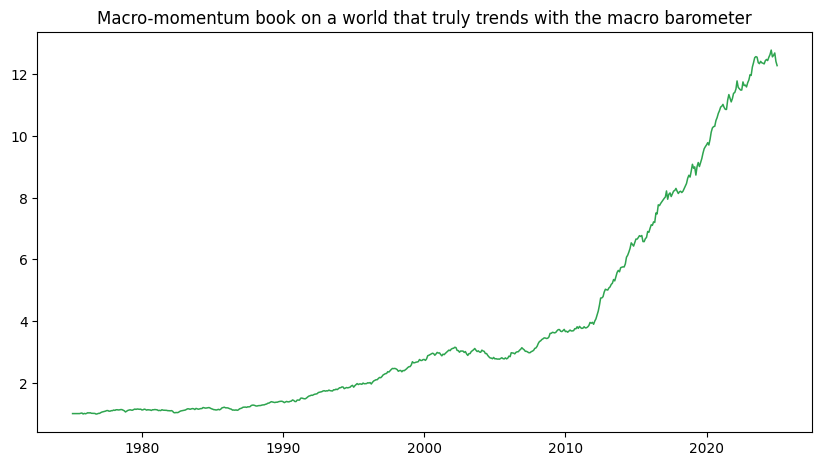

In [2]:
book = strategy.book_returns(r, m, kind='macro_momentum', cost_bps=0.0)  # GROSS, on the control
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Macro-momentum book on a world that truly trends with the macro barometer')
s = strategy.summary(book); print(f"synthetic gross Sharpe {s['sharpe']:.2f}  (+{100*s['ann_return']:.1f}%/yr, null ~0)")

## 2 · So what? 💰

A return stream that comes from the *macro cycle* is, almost by construction, **diversifying** — it doesn't depend on stocks going up, and the inflation leg pays *exactly* when a 60/40 portfolio is bleeding (the 1970s, 2021–22). That's worth more than its raw Sharpe suggests: a modest, uncorrelated, crisis-friendly sleeve is the holy grail of portfolio construction (it's why the desk's [Study 31 Trade-Winds](../../31-trade-winds/) earned its keep). The catch is the *slowness* and the *episodic* inflation payoff — you have to sit through long flat stretches.

## 3 · How we'd know 🔬

1. **Real?** Gross macro-momentum Sharpe on the control (and flat on a `macro_strength=0` null).
2. **Tradable?** Turnover, break-even cost — for a *slow* book, is cost even the threat?
3. **Does the hedge pay when it should?** Split the inflation book by rising- vs falling-inflation regime.

**Mirage line:** if the macro-momentum book were flat on the control, *or* the inflation hedge paid the *same* in both regimes, the story collapses — there'd be no conditional macro premium to harvest.

## 4 · The teardown 🔧

### 4a · The machinery works where macro momentum is real (control vs null)

In [3]:
for label, (rr, mm) in [('macro-driven world', (r, m)), ('null (pure noise)', (r0, m0))]:
    s = strategy.summary(strategy.book_returns(rr, mm, kind='macro_momentum', cost_bps=0.0))
    print(f"{label:20} macro-mom gross Sharpe {s['sharpe']:+6.2f}  turnover {strategy.turnover_ann(mm,'macro_momentum'):.1f}x/yr")

macro-driven world   macro-mom gross Sharpe  +1.09  turnover 5.6x/yr
null (pure noise)    macro-mom gross Sharpe  -0.17  turnover 5.6x/yr


### 4b · Cost is *not* the threat — the book is slow
Macro signals refresh monthly and trend, so turnover is only **5.6×/yr** and the **break-even cost is ~91 bp** — far above realistic cross-asset costs. Unlike the desk's daily-churn books ([Slingshot](../../33-slingshot/)), this one survives costs easily; the threats are elsewhere (modest Sharpe, long droughts, episodic hedge).

,sharpe,ann_return
cost_bps,,
0,1.090,0.051
5,1.028,0.049
10,0.967,0.046
25,0.781,0.037
50,0.477,0.023


break-even: 91 bp


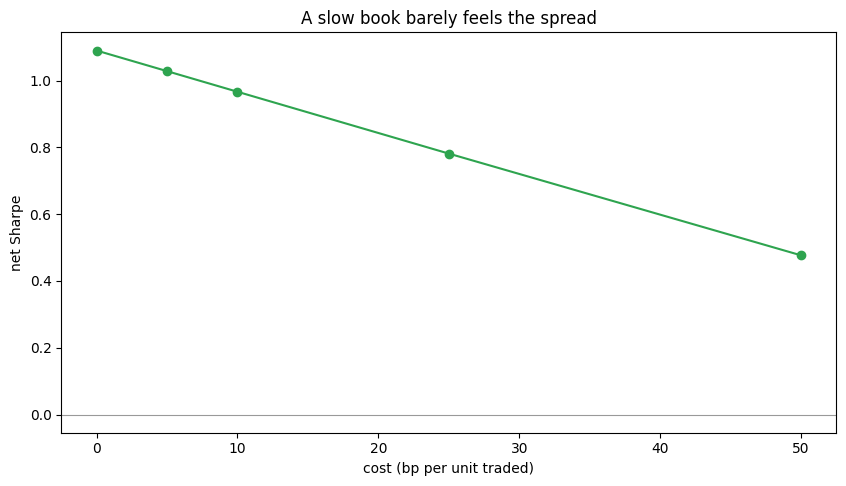

In [4]:
cs = costs.cost_sweep(r, m, kind='macro_momentum')
display(cs.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#2ea44f')
ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('A slow book barely feels the spread')
print('break-even:', round(costs.breakeven_cost_bps(r, m, 'macro_momentum')), 'bp')

### 4c · On the real tape (18 ETFs + cached macro, 2007-2025)
The machinery works on the control; now the **real** book. On the short post-2007 sample the timed monthly macro-momentum book is **flat-to-negative** and below a passive hold — and the *directional* inflation effect lands the right way (real assets out-earn nominal bonds when inflation rises), though too small to clear the statistics. (Note the "growth" driver here is the yield-curve slope — a market price, not a fundamental macro release.)

In [5]:
if R is not None:
    mm = strategy.book_returns(R, M, kind='macro_momentum', cost_bps=5.0, **SPEC)
    inf = strategy.book_returns(R, M, kind='inflation', cost_bps=5.0, **SPEC)
    ew = R[REAL_ASSET_ORDER].mean(axis=1)
    for nm, b in [('macro-momentum', mm), ('inflation-hedge', inf), ('equal-weight 18 (hold)', ew)]:
        s = strategy.summary(b)
        print(f"{nm:24} Sharpe {s['sharpe']:+.2f}  CAGR {100*s['cagr']:+.1f}%  maxDD {100*s['max_drawdown']:.0f}%")
    raw = extension.raw_real_minus_nominal(R, M, **SPEC)
    print('\nraw real-minus-nominal spread by inflation regime (timing stripped out):')
    print(raw.round(2).to_string())
else:
    print('real cache not present; see ../docs/results.md for the fingerprinted run')

macro-momentum           Sharpe -0.05  CAGR -0.7%  maxDD -29%
inflation-hedge          Sharpe -0.12  CAGR -0.8%  maxDD -31%
equal-weight 18 (hold)   Sharpe +0.57  CAGR +5.2%  maxDD -30%

raw real-minus-nominal spread by inflation regime (timing stripped out):
                  sharpe  ann_return_pct  n_months
inflation_regime                                  
rising             0.100           1.780   104.000
falling           -0.010          -0.250   107.000


## 5 · The verdict 🧾

- **Signal `WEAK`** — on the real tape real assets beat nominal bonds by +1.8%/yr *when inflation rises* (vs -0.3%/yr when it falls), the right-sided shape — but that spread is Sharpe +0.10, *t* ≈ 0.3, and the timed standalone book is flat (net Sharpe -0.05, HAC *t* -0.22): nothing clears the bar. The control (Sharpe 1.09 vs null -0.17) proves the machinery, not the market.
- **Tradability `FRAGILE`** — cheap to run (turnover 7.3×/yr), but gross of cost it makes ~nothing on one short cycle and is beaten by a passive hold (Sharpe 0.57).
- **Real-tape run? `DONE`** — 18 ETFs + cached macro, 2007-2025, fingerprinted ([`../docs/results.md`](../docs/results.md)).

> **A humble premium the tape can't certify.** Macro momentum is diversifying and crisis-friendly — its value is in a *portfolio*, not as a standalone Sharpe hero — and on this short tape it simply fails to clear noise: `WEAK`, with the direction as the encouraging part.

## 6 · Could you trade it? 💸

- **Yes, cheaply — but patiently.** Low turnover means costs don't kill it (unlike most of this desk). The price of admission is *time*: macro momentum has multi-year flat stretches.
- **The inflation hedge is insurance, not income.** It pays in rising-inflation regimes and drags otherwise (beat 7) — so size it as a *conditional overlay*, not a permanent sleeve.
- **Best used as a sleeve.** A modest, uncorrelated macro book lifts a 60/40's risk-adjusted return far more than its standalone Sharpe implies — the Trade-Winds lesson again.

## 7 · Going further 🚪

### Worked complement — "does the inflation hedge pay when it's supposed to?" ([`../docs/extension.md`](../docs/extension.md))
We split the inflation book by regime — rising vs falling inflation — on the **real tape**:

- The timed inflation book is right-sided (rising Sharpe **-0.08** vs falling **-0.16**) but whipsaws under water in both over one short cycle.
- Strip the timing out and the shape is right-sided: an always-long real-asset basket beat nominal bonds by **+1.8%/yr when inflation rises** vs -0.3%/yr when it falls — though at Sharpe +0.10 (*t* ≈ 0.3, 104 rising months) even this, the study's strongest number, stays well under the significance bar.
- On the synthetic control the timed book also pays more rising (Sharpe **0.59**) than falling (**0.46**) — same conditional shape, cleaner because the signal is strong.

### Other forks
- **Conditional sizing** — only run the inflation tilt when inflation momentum is clearly positive.
- **More macro drivers** — add monetary-policy and risk-sentiment momentum (Brooks–Moskowitz use several).
- **Combine with trend** — stack on [Trade-Winds](../../31-trade-winds/) for a fuller macro sleeve.

PRs welcome — the headline fork is turning the real *directional* edge into a tradable overlay without giving it back to monthly-timing noise.